<a href="https://colab.research.google.com/github/withspencerr/ab-testing-toolkit/blob/main/ab_testing_toolkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

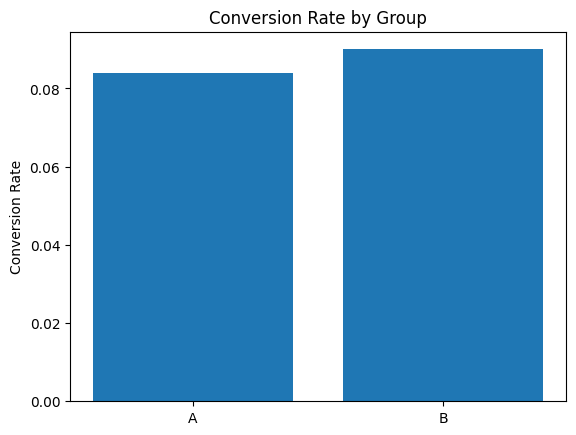

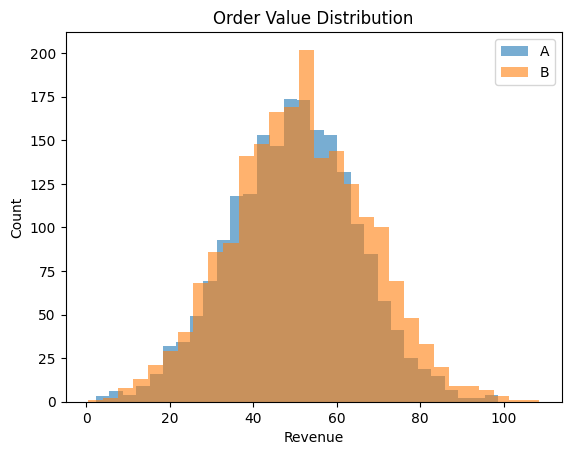

=== Conversion (Binary) ===
A: 168/2000 = 8.400%
B: 180/2000 = 9.000%
Lift (B-A): 0.60%
Proportion z-test p-value (B>A): 0.7496

=== Revenue (Continuous) ===
A mean: 49.72, B mean: 51.31
T-test p-value (two-sided): 0.0015

=== Power & Sample Size (rough) ===
Target MDE: 1.50%, Required per group (approx): 4366


In [2]:
# A/B Testing Toolkit – Colab Minimal
# 功能：二项转化率检验、均值检验、功效&样本量、可视化
# 你只需运行整段代码，会自动生成示例数据和图

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

np.random.seed(42)

# ===== 1) 生成示例数据：A/B 两组转化率 =====
n_A, n_B = 2000, 2000
p_A, p_B = 0.08, 0.095  # 假设 B 组略好
A = np.random.binomial(1, p_A, size=n_A)
B = np.random.binomial(1, p_B, size=n_B)

conv_A, conv_B = A.sum(), B.sum()
rate_A, rate_B = conv_A/n_A, conv_B/n_B
lift = rate_B - rate_A

# 二项检验（转化率）
stat, pval = proportions_ztest([conv_A, conv_B], [n_A, n_B], alternative='larger')

# ===== 2) 均值类指标（如客单价）示例 =====
mu_A, mu_B = 50, 52   # 平均客单价
sd_A, sd_B = 15, 16
rev_A = np.random.normal(mu_A, sd_A, size=n_A)
rev_B = np.random.normal(mu_B, sd_B, size=n_B)
t_stat, t_pval = stats.ttest_ind(rev_B, rev_A, equal_var=False)

# ===== 3) 功效分析 & 样本量估算（简单近似）=====
# 目标：检测最小可检测效应(MDE)：如转化率差 1.5 个百分点
alpha = 0.05
power_target = 0.8
p_pool = (rate_A + rate_B)/2
mde = 0.015

# 正态近似样本量（两比例，双样本，单侧简化）
z_alpha = stats.norm.ppf(1 - alpha)
z_beta = stats.norm.ppf(power_target)
n_per_group = ((z_alpha*np.sqrt(2*p_pool*(1-p_pool)) + z_beta*np.sqrt(rate_A*(1-rate_A)+rate_B*(1-rate_B)))**2) / (mde**2)
n_per_group = int(np.ceil(n_per_group))

# ===== 4) 可视化 =====
plt.figure()
plt.bar(['A','B'], [rate_A, rate_B])
plt.title('Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.show()

plt.figure()
plt.hist(rev_A, bins=30, alpha=0.6, label='A')
plt.hist(rev_B, bins=30, alpha=0.6, label='B')
plt.title('Order Value Distribution')
plt.xlabel('Revenue'); plt.ylabel('Count'); plt.legend()
plt.show()

# ===== 5) 输出摘要 =====
print("=== Conversion (Binary) ===")
print(f"A: {conv_A}/{n_A} = {rate_A:.3%}")
print(f"B: {conv_B}/{n_B} = {rate_B:.3%}")
print(f"Lift (B-A): {lift:.2%}")
print(f"Proportion z-test p-value (B>A): {pval:.4f}")

print("\n=== Revenue (Continuous) ===")
print(f"A mean: {rev_A.mean():.2f}, B mean: {rev_B.mean():.2f}")
print(f"T-test p-value (two-sided): {t_pval:.4f}")

print("\n=== Power & Sample Size (rough) ===")
print(f"Target MDE: {mde:.2%}, Required per group (approx): {n_per_group}")
